Predictive model project

Import Libriaries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

Load data

In [2]:
data = pd.read_csv('/content/human_cognitive_performance.csv')

In [3]:
data.head()

,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
0,U1,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71,39.77
1,U2,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35,57.68
2,U3,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57,29.54
3,U4,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15,74.59
4,U5,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54,91.78


The columns for the supervised Learning

In [4]:
# Define features and target for supervised learning
X = data.drop(columns=['User_ID', 'AI_Predicted_Score'])  # Features
y = data['AI_Predicted_Score']  # Target

# Define categorical and numerical columns
categorical_cols = ['Gender', 'Diet_Type']
ordinal_cols = ['Exercise_Frequency']
numerical_cols = ['Age', 'Sleep_Duration', 'Stress_Level', 'Daily_Screen_Time',
                 'Caffeine_Intake', 'Reaction_Time', 'Memory_Test_Score', 'Cognitive_Score']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
        ('ord', OrdinalEncoder(categories=[['Low', 'Medium', 'High']]), ordinal_cols),
        ('num', StandardScaler(), numerical_cols)
    ])

Step 2: Supervised Learning - Linear Regression

Mean Squared Error: 8.03
R^2 Score: 0.98

Feature Coefficients:
                 Feature  Coefficient
12       Cognitive_Score    24.296041
10         Reaction_Time     1.081732
11     Memory_Test_Score    -0.503341
4     Exercise_Frequency    -0.443804
7           Stress_Level     0.324885
8      Daily_Screen_Time     0.286798
6         Sleep_Duration    -0.197138
9        Caffeine_Intake     0.182920
2        Diet_Type_Vegan     0.049948
0            Gender_Male    -0.023269
5                    Age    -0.017821
1           Gender_Other     0.016405
3   Diet_Type_Vegetarian     0.010428


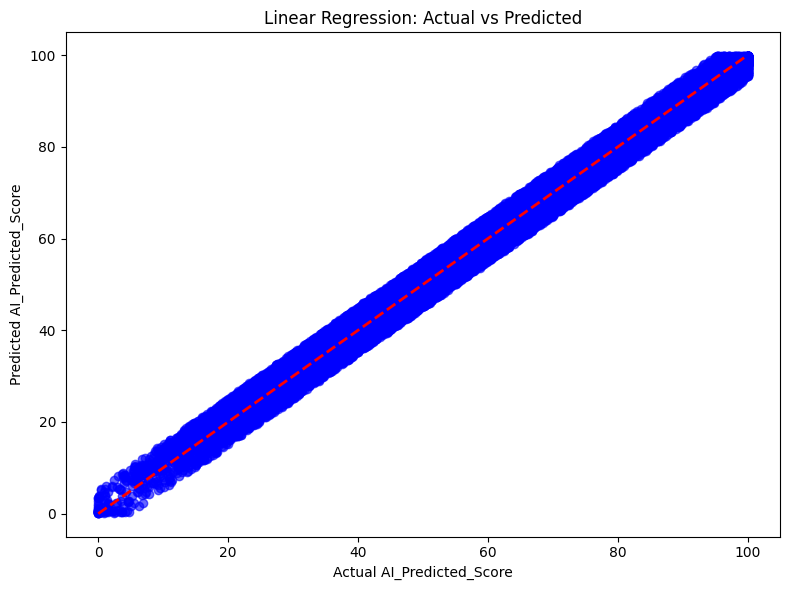

In [5]:
# Create pipeline with preprocessing and model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
pipeline.fit(X_train, y_train)

# Predict on test set
y_pred = pipeline.predict(X_test)

# Evaluate: MSE and R^2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

# Feature importance (coefficients)
# Get feature names after one-hot encoding
cat_features = (pipeline.named_steps['preprocessor']
                .named_transformers_['cat']
                .get_feature_names_out(categorical_cols)).tolist()
ord_features = ordinal_cols
num_features = numerical_cols
all_features = cat_features + ord_features + num_features

# Get coefficients
coefficients = pipeline.named_steps['model'].coef_
coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coefficients})
print("\nFeature Coefficients:")
print(coef_df.sort_values(by='Coefficient', key=abs, ascending=False))

# Plot actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual AI_Predicted_Score')
plt.ylabel('Predicted AI_Predicted_Score')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()